<a href="https://colab.research.google.com/github/yadavkhushnoor-ai/ml-/blob/main/Project1_logistic_regression_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [ ]:
df = pd.read_csv('/content/heart (1).csv')
print("First 5 rows:\n", df.head())

First 5 rows:
    age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [ ]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [ ]:
X = df.drop('target', axis=1)
y = df['target']


In [ ]:
X = df.drop('target', axis=1)
y = df['target']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)


In [ ]:
acc_log = accuracy_score(y_test, y_pred_log)
cm_log = confusion_matrix(y_test, y_pred_log)

print("\n=== Logistic Regression ===")
print("Accuracy:", acc_log)
print("\nConfusion Matrix:\n", cm_log)
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))



=== Logistic Regression ===
Accuracy: 0.7951219512195122

Confusion Matrix:
 [[73 29]
 [13 90]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205



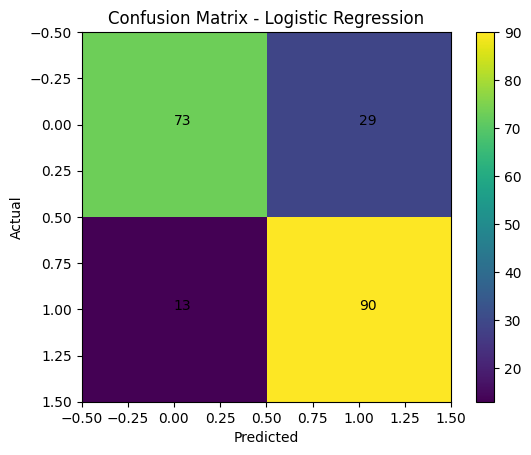

In [ ]:
plt.figure()
plt.imshow(cm_log)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm_log)):
    for j in range(len(cm_log[0])):
        plt.text(j, i, cm_log[i][j])

plt.colorbar()
plt.show()

In [ ]:
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

y_pred_lin = lin_model.predict(X_test)

# Convert to class (0 or 1)
y_pred_lin_class = [1 if i > 0.5 else 0 for i in y_pred_lin]

acc_lin = accuracy_score(y_test, y_pred_lin_class)
cm_lin = confusion_matrix(y_test, y_pred_lin_class)

print("\n=== Linear Regression (for comparison) ===")
print("Accuracy:", acc_lin)
print("\nConfusion Matrix:\n", cm_lin)


=== Linear Regression (for comparison) ===
Accuracy: 0.8195121951219512

Confusion Matrix:
 [[72 30]
 [ 7 96]]


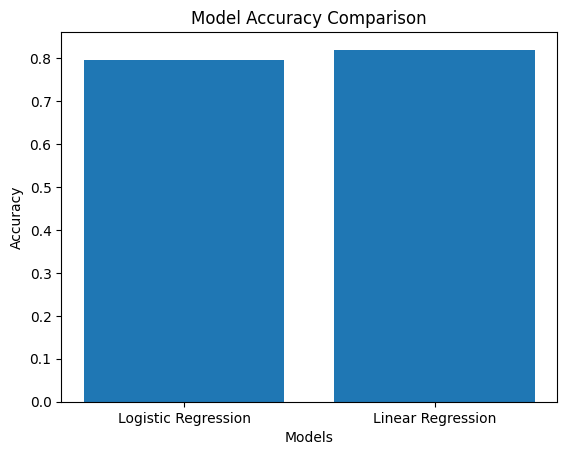

In [ ]:
models = ['Logistic Regression', 'Linear Regression']
accuracies = [acc_log, acc_lin]

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

ROC **Curve**

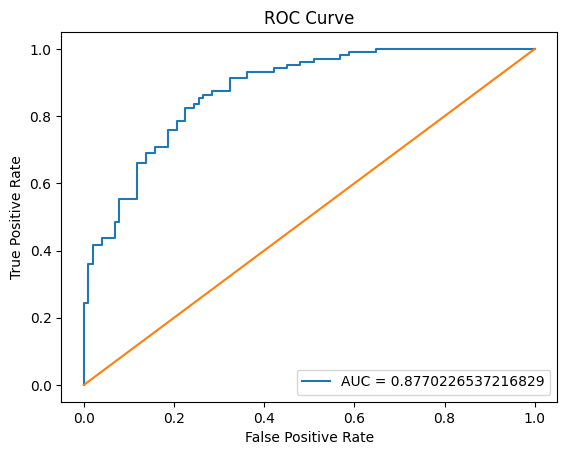

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = log_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="AUC = " + str(roc_auc))
plt.plot([0,1], [0,1])  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
})

print("\nFeature Importance:\n", importance.sort_values(by='Coefficient', ascending=False))


Feature Importance:
      Feature  Coefficient
2         cp     0.847057
10     slope     0.535876
6    restecg     0.262391
7    thalach     0.028880
0        age     0.000642
4       chol    -0.008867
3   trestbps    -0.018159
5        fbs    -0.164529
9    oldpeak    -0.679894
11        ca    -0.814054
8      exang    -0.835868
12      thal    -1.072174
1        sex    -1.714708


In [ ]:
y_pred_custom = [1 if i > 0.6 else 0 for i in y_prob]

print("New Accuracy:", accuracy_score(y_test, y_pred_custom))

New Accuracy: 0.7804878048780488


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(log_model, X, y, cv=5)
print("Cross Validation Accuracy:", scores.mean())

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Cross Validation Accuracy: 0.8497560975609757


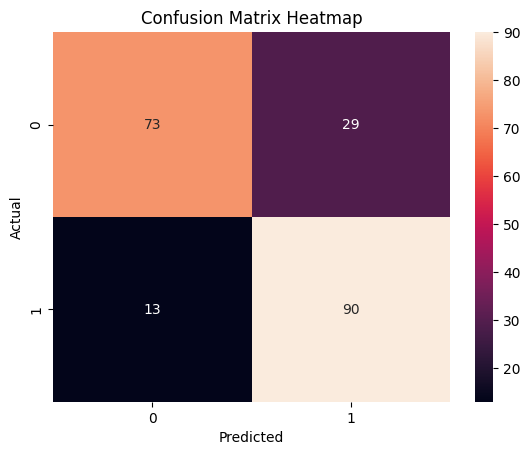

In [ ]:
import seaborn as sns

sns.heatmap(cm_log, annot=True, fmt='d')
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()